In [2]:
import os, sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from common.util import smooth_curve
from my_models import *
from my_functions import *


In [3]:
np.random.seed(42)
node_num = 100
batch_size = 128
iters = 2000

In [4]:
(x_train, t_train),(x_test, t_test) = load_mnist(True, True)

batch_mask = np.random.choice(x_train.shape[0], 100)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
x_batch.shape

(100, 784)

In [6]:
network =  MultiLayerNet(784, [100], 10)
for key, value in network.params.items():
    print(f'{key}: {value.shape}')
    

W1: (784, 100)
b1: (100,)
W2: (100, 10)
b2: (10,)


In [11]:
(x_train, t_train),(x_test, t_test) = load_mnist(True, True)


weight_init_dict = {
    'std=1': 1,
    'std=0.01': 0.01,
    'xavier': 'sigmoid',
    'he': 'relu'
}

loss_dict = defaultdict(list)

for key, weight_init_scale in weight_init_dict.items():
    network = MultiLayerNet(784, [100], 10, weight_init_std=weight_init_scale)
    optimizer = SGD(lr=0.01)
    
    for i in range(iters):
        batch_mask = np.random.choice(x_train.shape[0], batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
        
        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)
        
        loss = network.loss(x_batch, t_batch)
        loss_dict[key].append(loss)
        if i % 100 == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            print(train_acc, test_acc)
        
        

    

0.08221666666666666 0.0807
0.44206666666666666 0.4665
0.5735166666666667 0.5949
0.6379 0.6567
0.6786 0.6947


KeyboardInterrupt: 

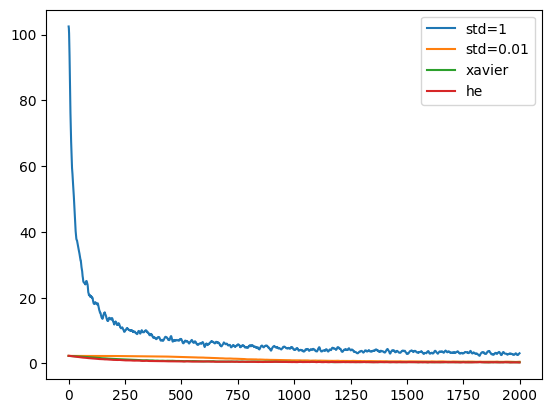

In [ ]:
for key, value in loss_dict.items():
    plt.plot(np.arange(iters), smooth_curve(value), label = key)
    

plt.ylim(0, 2.5)
plt.legend()